In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

In [3]:
df=pd.read_csv('Employee attrition.csv')
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [6]:
if 'Employee ID' in df.columns:
    df.drop(columns=['Employee ID'], inplace=True)

In [8]:
label_encoders={}
for col in df.select_dtypes(include=['object']).columns:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    label_encoders[col]=le

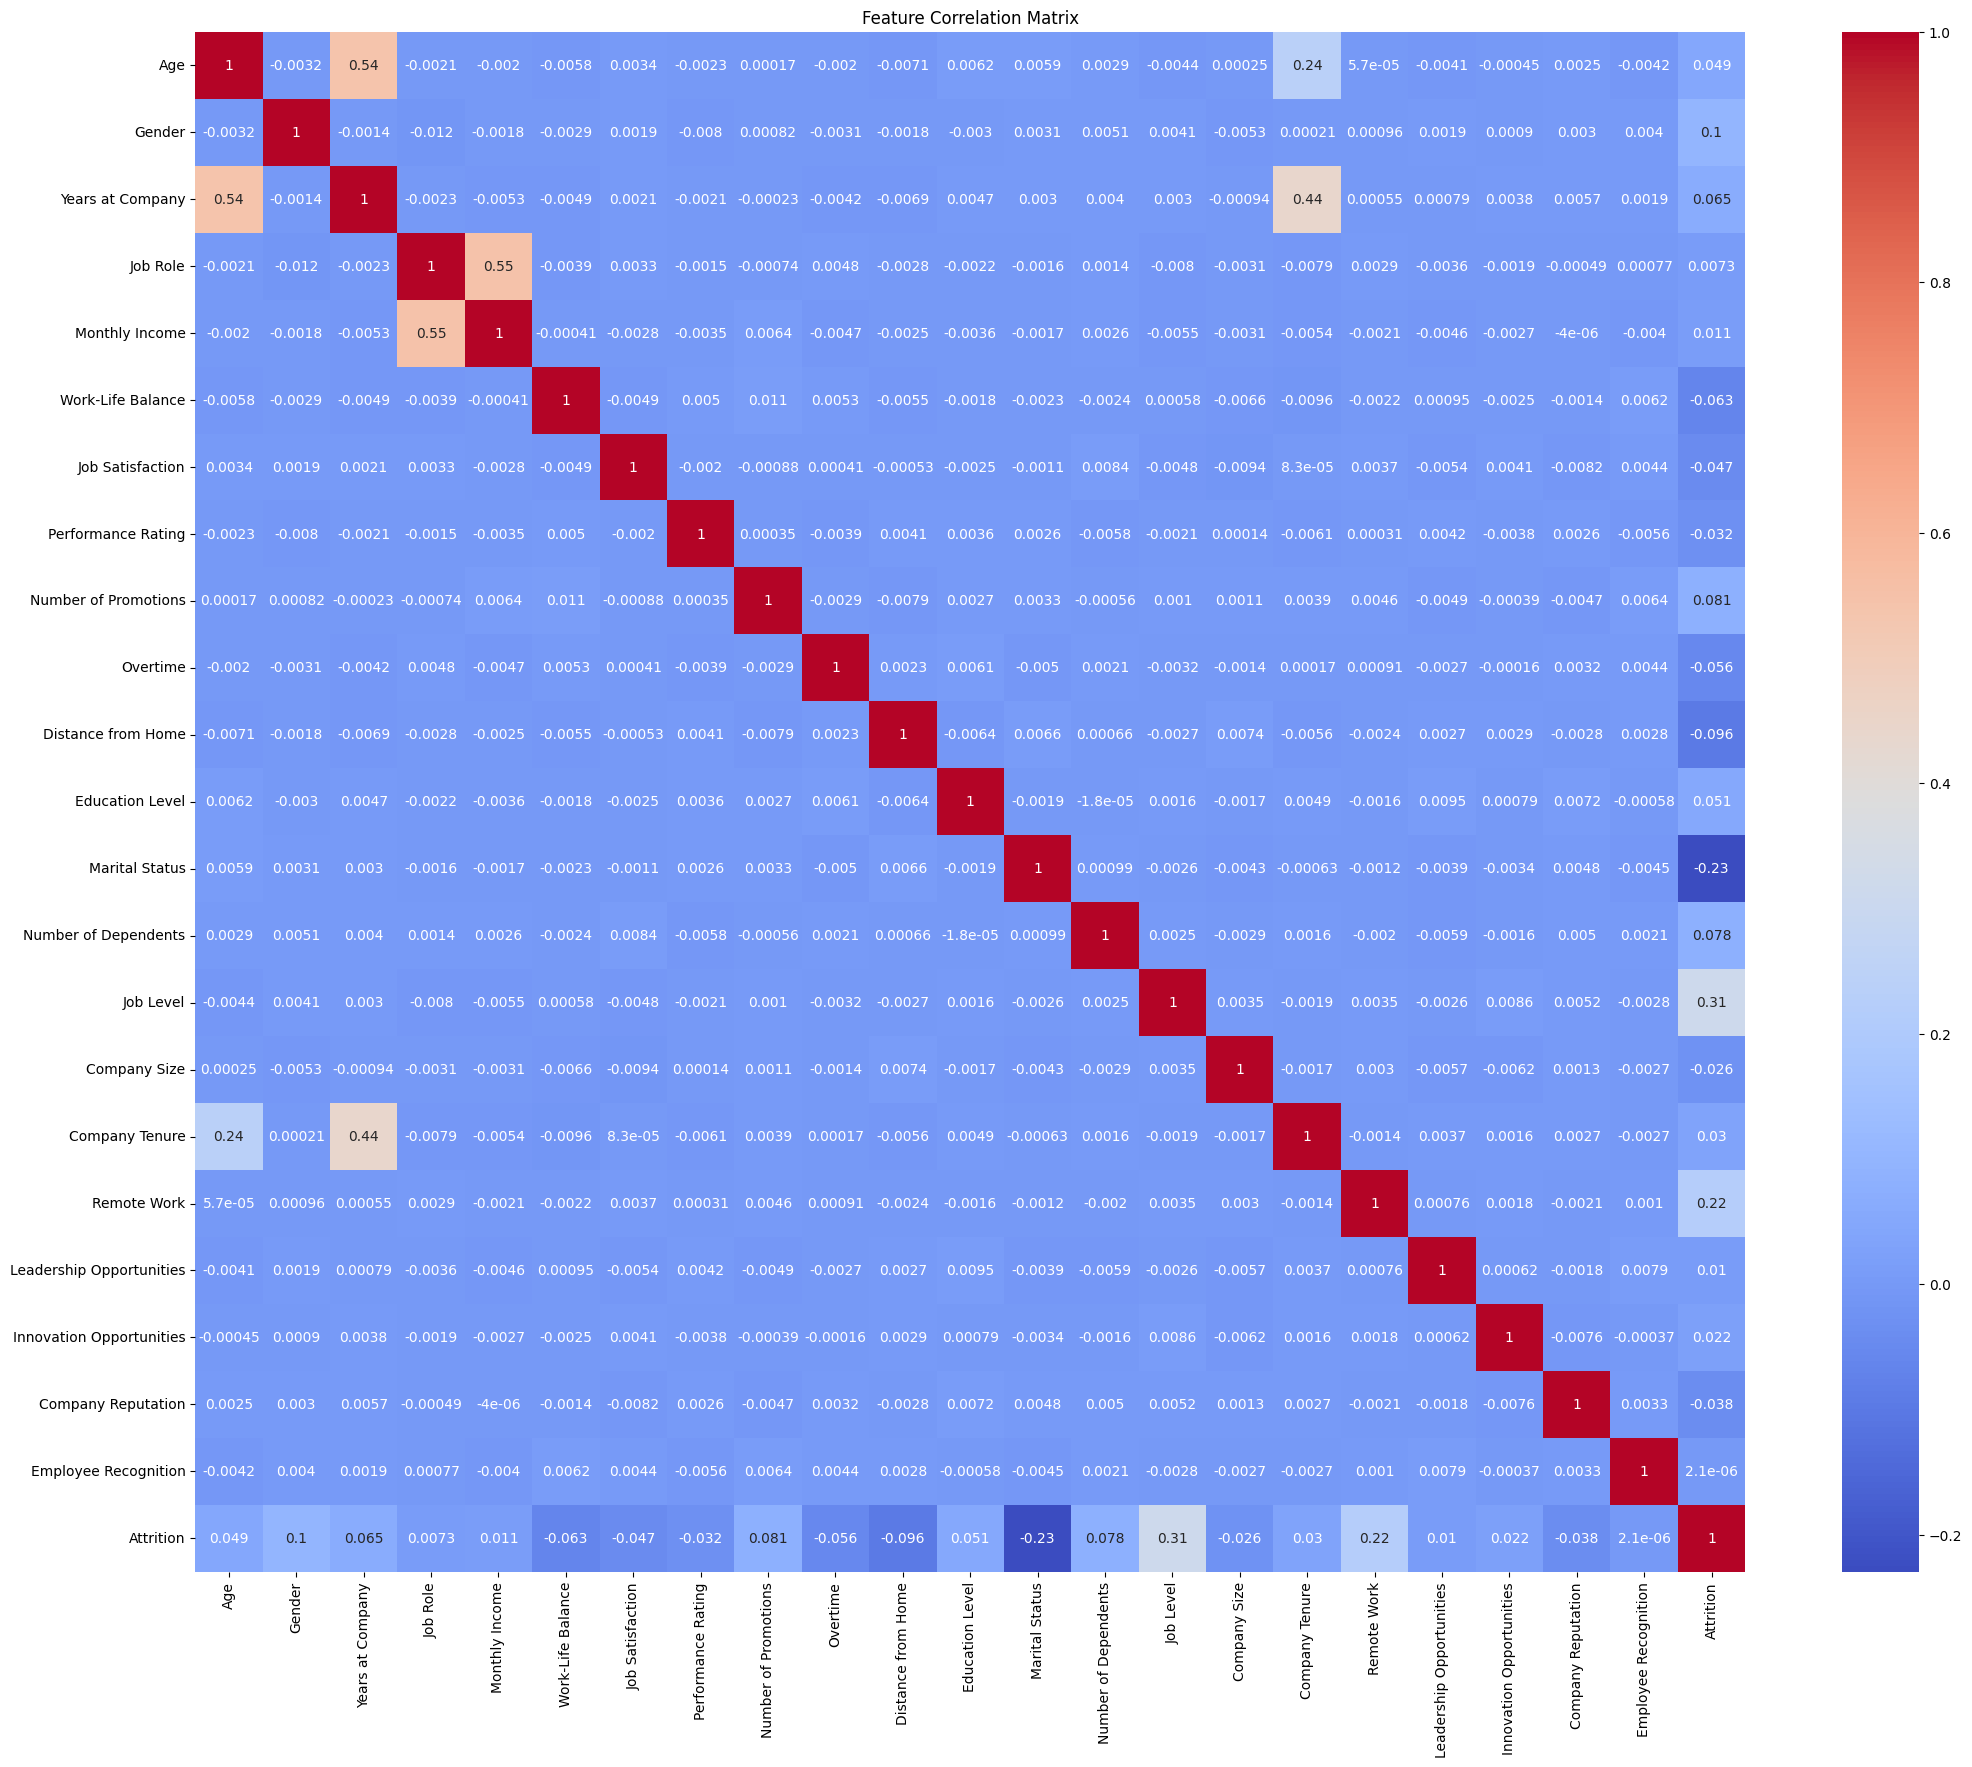

In [12]:
plt.figure(figsize=(25, 20))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [13]:
X=df.drop(columns=['Attrition']) 
Y=df['Attrition']

In [17]:
df['Attrition'].value_counts()

Attrition
1    31260
0    28338
Name: count, dtype: int64

In [23]:
smote=SMOTE(random_state=42)
X_resampled, Y_resampled=smote.fit_resample(X, Y)
print("Before:", Y.value_counts())
print("After:", Y_resampled.value_counts())

Before: Attrition
1    31260
0    28338
Name: count, dtype: int64
After: Attrition
1    31260
0    31260
Name: count, dtype: int64


In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [25]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [28]:
params={
    'n_estimators': [50, 100],
    'max_depth':[5, 10, None]
}

grid=GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, Y_train)

print("Best params:", grid.best_params_)

Best params: {'max_depth': 10, 'n_estimators': 100}


In [29]:
best_params=grid.best_params_
print(f"Best hyperparameters: {best_params}")

best_rf=RandomForestClassifier(**best_params, random_state=42)
best_rf.fit(X_train, Y_train)

Best hyperparameters: {'max_depth': 10, 'n_estimators': 100}


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           0       0.73      0.73      0.73      5668
           1       0.76      0.76      0.76      6252

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



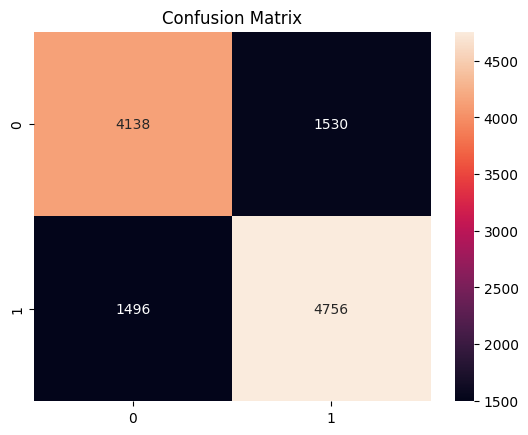

In [32]:
Y_pred=best_rf.predict(X_test)
print(classification_report(Y_test, Y_pred))
sns.heatmap(confusion_matrix(Y_test, Y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

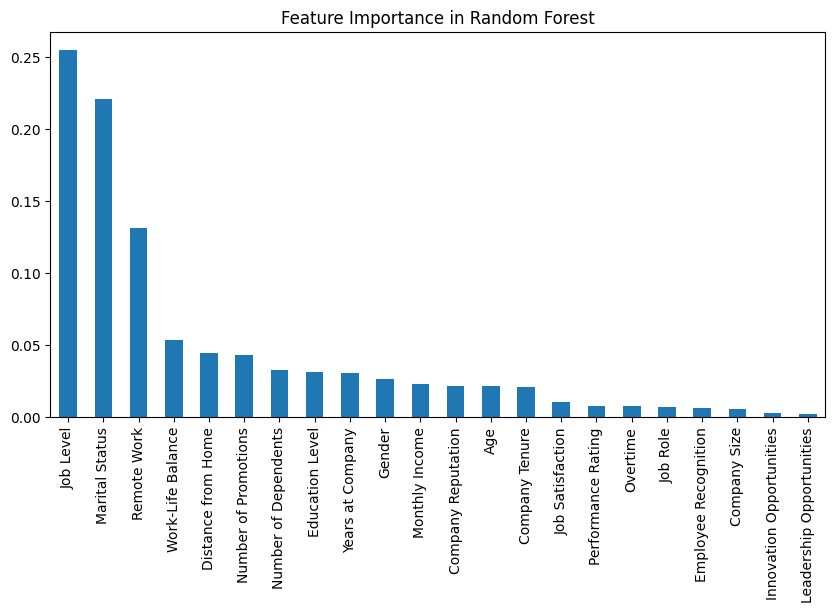

In [33]:
feature_importances=pd.Series(best_rf.feature_importances_, index=df.drop(columns=['Attrition']).columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), title="Feature Importance in Random Forest")
plt.show()

In [45]:
adaboost = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)
adaboost.fit(X_train, Y_train)

gradboost=GradientBoostingClassifier(n_estimators=100,learning_rate=0.6, max_depth=3, random_state=42)
gradboost.fit(X_train, Y_train)

,loss,'log_loss'
,learning_rate,0.6
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [48]:
models={
    "Random Forest": best_rf,
    "AdaBoost":adaboost,
    "Gradient Boosting": gradboost
}
for name, model in models.items():
    print(f"\n{name} Performance:")
    Y_pred=model.predict(X_test)
    accuracy=accuracy_score(Y_test, Y_pred)
    print(f"Accuracy:{accuracy:.4f}")
    print('Classification Report:\n', classification_report(Y_test, Y_pred))
    print("Confusion Matrix:", confusion_matrix(Y_test, Y_pred))


Random Forest Performance:
Accuracy:0.7461
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73      5668
           1       0.76      0.76      0.76      6252

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920

Confusion Matrix: [[4138 1530]
 [1496 4756]]

AdaBoost Performance:
Accuracy:0.7483
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.74      0.74      5668
           1       0.76      0.76      0.76      6252

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920

Confusion Matrix: [[4185 1483]
 [1517 4735]]

Gradient Boosting Performance:
Accuracy:0.7558
Classification Report:
               precision    recall  f1-score   support

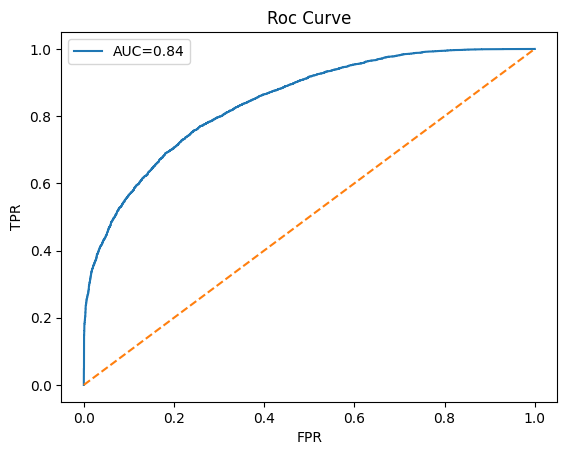

In [54]:
Y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _=roc_curve(Y_test, Y_prob)
roc_auc=auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Roc Curve")
plt.legend()
plt.show()